# Models 10 and 11 - Start service after some time with no arrival, $b_{S,\min}=12$ (diagrams for paper)

## Load libraries

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import libs.tools as tools

plt.style.use('seaborn-v0_8')

## Load and process data

In [2]:
# Number of operators needed in bS=1 case
c_needed = 16

data_bI1 = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "time-last" and rec["b_min"] == 12 and isinstance(rec["bI"], int))
base_data_bI1 = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "fixed" and rec["b_min"] == 16 and isinstance(rec["bI"], int))
tools.load_statistics(data_bI1)
tools.load_statistics(base_data_bI1)

data_bI1234 = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "time-last" and rec["b_min"] == 12 and isinstance(rec["bI"], str))
base_data_bI1234 = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "fixed" and rec["b_min"] == 16 and isinstance(rec["bI"], str))
tools.load_statistics(data_bI1234)
tools.load_statistics(base_data_bI1234)

### Calculate E[W] increasement relative to no early release case

In [3]:
for rec in data_bI1:
    save_mode = rec["mode"]
    rec["mode"] = "fixed"
    base = tools.find_same_with_other_b(base_data_bI1, rec, 1, c_needed, c_needed, None)
    rec["mode"] = save_mode
    rec["E[W]rel"] = rec["E[W]"] / base["E[W]"]

### Calculate E[W] increasement relative to no early release and $b_I$=(1,1,1,1) case

In [4]:
for rec in data_bI1234:
    save_mode = rec["mode"]
    rec["mode"] = "fixed"
    base = tools.find_same_with_other_b(base_data_bI1234, rec, "1111", c_needed, c_needed, None)
    rec["mode"] = save_mode
    rec["E[W]rel"] = rec["E[W]"] / base["E[W]"]

## Plot results

### Setup plot

In [5]:
bI_rates_levels = [
    [1, 1, 1, 1],
    [1, 2, 3, 4],
    [4, 3, 2, 1],
    [1, 2, 2, 1],
    [2, 1, 1, 2]
]

colors = ["blue", "red", "green", "orange", "purple"]

bS_colors=[
    '#F00',
    '#E01',
    '#D02',
    '#C03',
    '#B04',
    '#A05',
    '#906',
    '#807',
    '#708',
    '#609',
    '#50A',
    '#40B',
    '#30C',
    '#20D',
    '#10E',
    '#00F'
]

### Plot E[W] (relative), $b_I$=1 (Model 10)

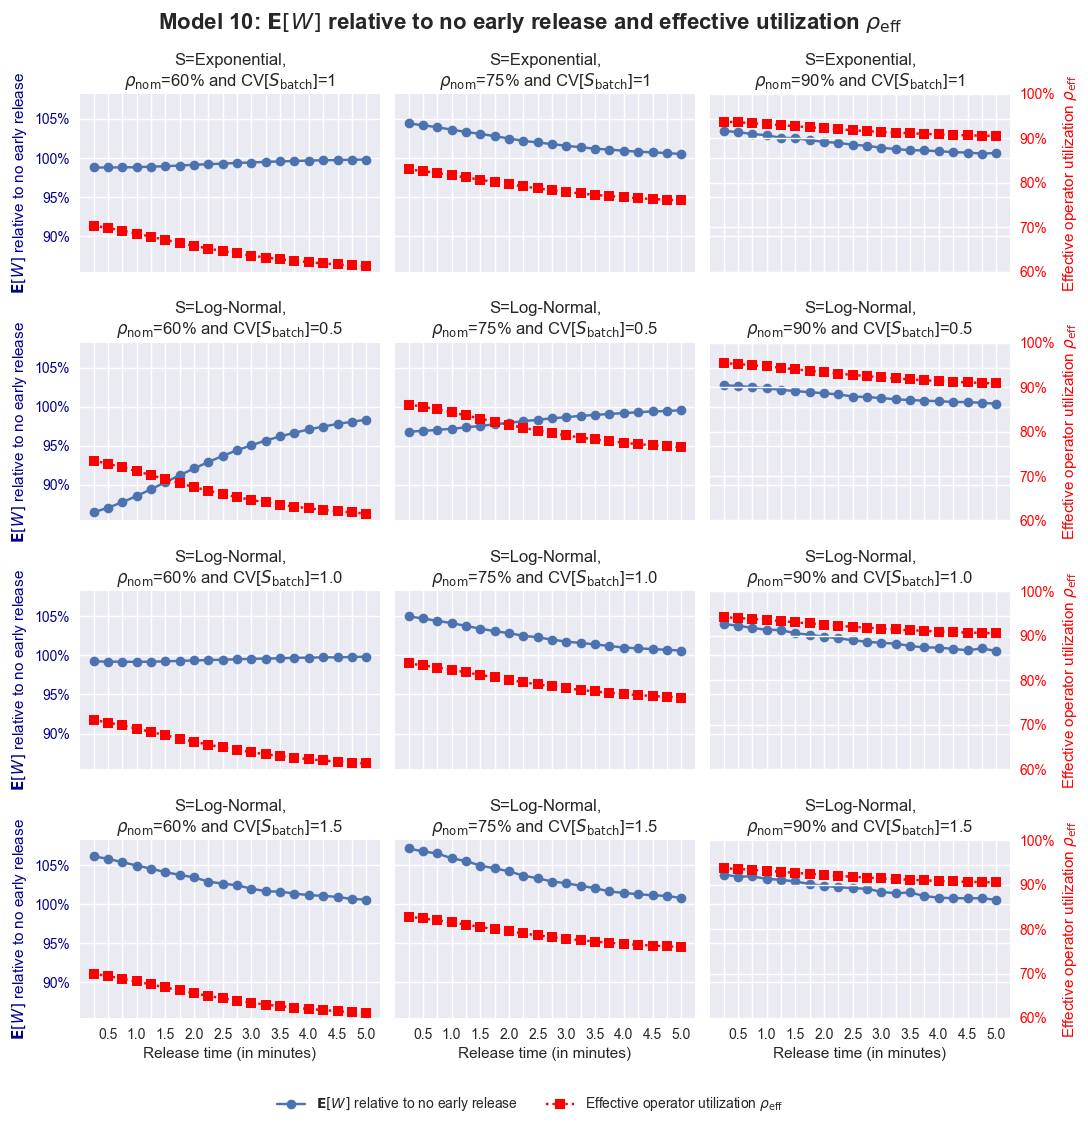

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        S_name = "Exponential"
        CVS = 1
    else:
        S = "Log"
        S_name = "Log-Normal"
        CVS = 0.5 * i
    for j in range(3):
        rho = round(0.60 + j * 0.15, 2)
        plot_sim_data = []
        for rec in [r for r in data_bI1 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            time = rec["time"]
            name = rec["name_short"]
            plot_sim_data.append({"time": time, "name": name, "E[W]": rec["E[W]rel"], "rho": rec["rho"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["time"])

        x = [rec["time"] / 60 for rec in plot_sim_data]
        y_sim = [rec["E[W]"] for rec in plot_sim_data]
        y2_sim = [rec["rho"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        if i == 0 and j == 0:
            ax1.plot(x, y_sim, marker='o', label="$\\mathbf{{E}}[W]$ relative to no early release")
        else:
            ax1.plot(x, y_sim, marker='o')
        ax1.set_xticks(x)
        for label in ax1.xaxis.get_ticklabels()[::2]:
            label.set_visible(False)
        ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        if j == 0:
            ax1.set_ylabel("$\\mathbf{{E}}[W]$ relative to no early release", color="darkblue")
            ax1.tick_params(axis='y', colors='darkblue')
        if i == 3:
            ax1.set_xlabel("Release time (in minutes)")
        ax1.set_title(f"S={S_name},\n$\\rho_{{\\text{{nom}}}}$={rho * 100:0.0f}% and CV[$S_{{\\text{{batch}}}}$]={CVS}")

        ax2 = ax1.twinx()
        if i == 0 and j == 0:
            ax2.plot(x, y2_sim, 'r:', marker='s', label='Effective operator utilization $\\rho_{\\text{eff}}$')
        else:
            ax2.plot(x, y2_sim, 'r:', marker='s')
        if j == 2:
            ax2.set_ylabel("Effective operator utilization $\\rho_{\\text{eff}}$", color="red")
            ax2.tick_params(axis='y', colors='red')
        else:
            ax2.set_yticks([])
        ax2.set_ylim([0.6, 1])
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

fig.suptitle("Model 10: $\\mathbf{E}[W]$ relative to no early release and effective utilization $\\rho_{\\text{eff}}$", fontsize=16, fontweight="semibold", y=0.95)
fig.legend(loc='outside lower center', ncols=2, bbox_to_anchor=(0.5, 0.02), fontsize=10)
fig.subplots_adjust(wspace=0.05, hspace=0.4)

# fig.savefig("images/Model10-EWrel.png", format="png", bbox_inches='tight', pad_inches=0)

# fig.savefig("images/BatchArithmeticAndMitigation-figure-results-Model10-EWrel.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

### Plot CV[W], $b_I$=1 (Model 10)

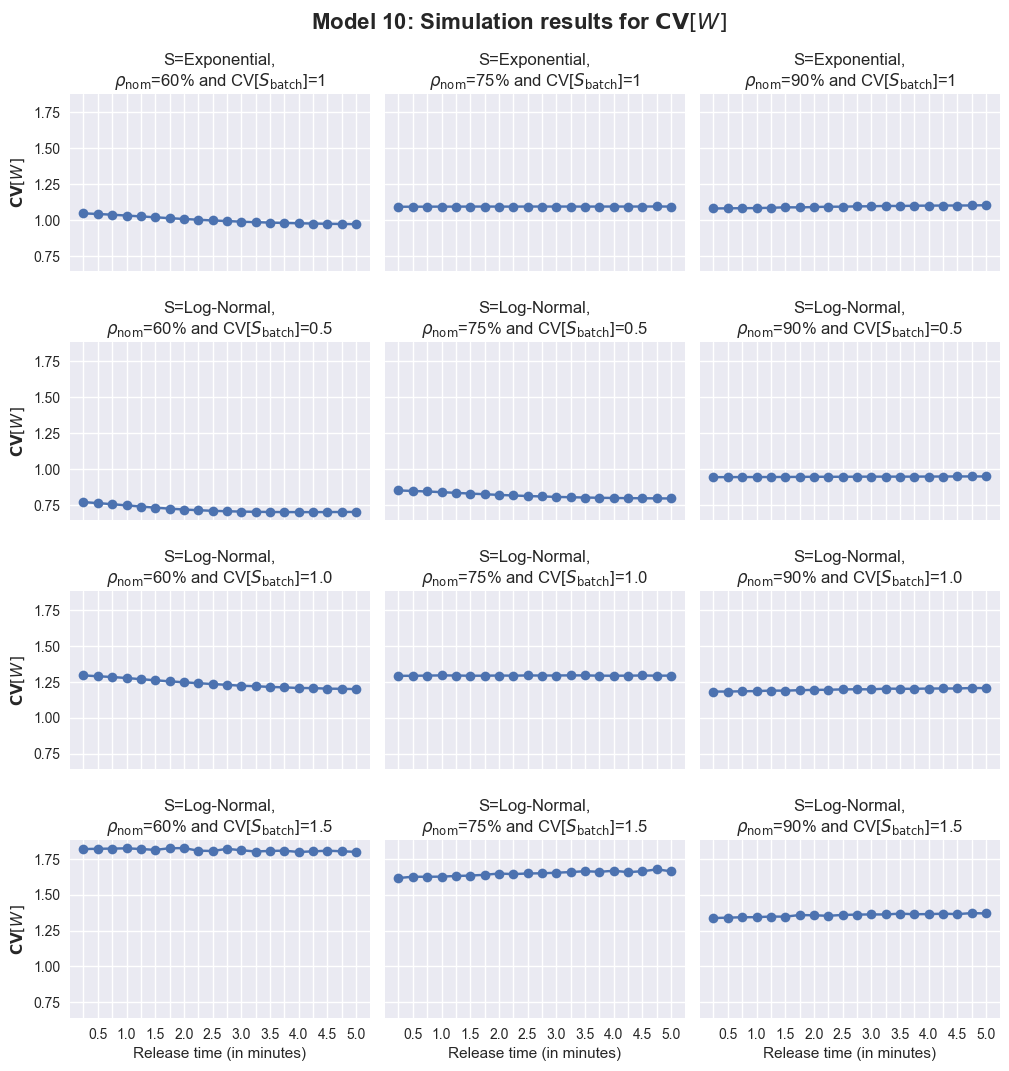

In [7]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        S_name = "Exponential"
        CVS = 1
    else:
        S = "Log"
        S_name = "Log-Normal"
        CVS = 0.5 * i
    for j in range(3):
        rho = round(0.60 + j * 0.15, 2)
        plot_sim_data = []
        for rec in [r for r in data_bI1 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            time = rec["time"]
            name = rec["name_short"]
            plot_sim_data.append({"time": time, "name": name, "CV[W]": rec["CV[W]"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["time"])

        x = [rec["time"] / 60 for rec in plot_sim_data]
        y_sim = [rec["CV[W]"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o')
        ax1.set_xticks(x)
        ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
        for label in ax1.xaxis.get_ticklabels()[::2]:
            label.set_visible(False)
        if j == 0:

            ax1.set_ylabel("$\\mathbf{{CV}}[W]$")
        if i == 3:
            ax1.set_xlabel("Release time (in minutes)")

        ax1.set_title(f"S={S_name},\n$\\rho_{{\\text{{nom}}}}$={rho * 100:0.0f}% and CV[$S_{{\\text{{batch}}}}$]={CVS}")

fig.suptitle("Model 10: Simulation results for $\\mathbf{CV}[W]$", fontsize=16, fontweight="semibold", y=0.95)
fig.subplots_adjust(wspace=0.05, hspace=0.4)

# fig.savefig("images/Model10-CVW.png", format="png", bbox_inches='tight', pad_inches=0)

### Plot batch sizes frequencies for $b_I=1$ (Model 10)

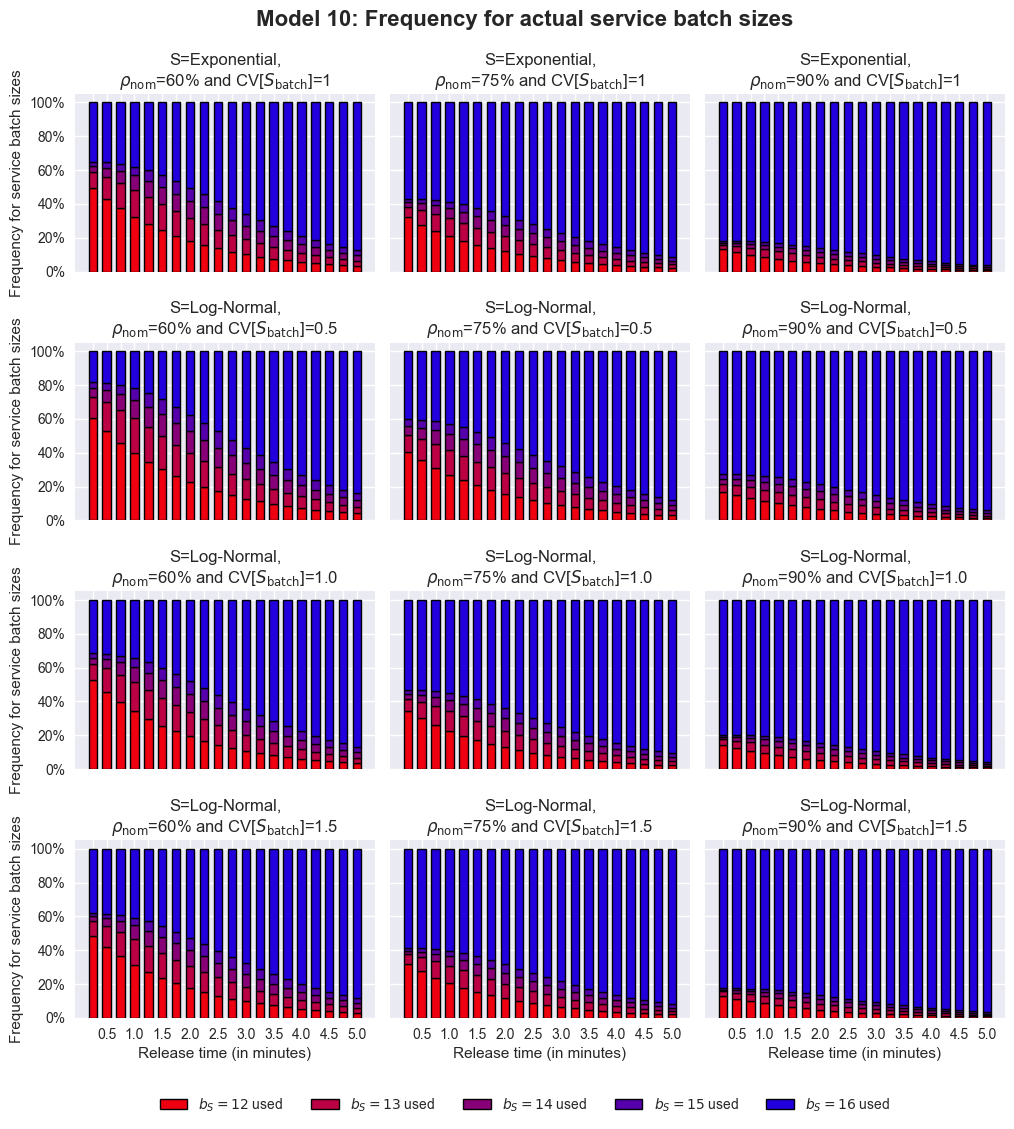

In [8]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        S_name = "Exponential"
        CVS = 1
    else:
        S = "Log"
        S_name = "Log-Normal"
        CVS = 0.5 * i
    for j in range(3):
        rho = round(0.60 + j * 0.15, 2)
        plot_sim_data = []
        for rec in [r for r in data_bI1 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            time = rec["time"]
            name = rec["name_short"]
            plot_sim_data.append({"time": time, "name": name, "batch_sizes": rec["batch_sizes"], "rho": rec["rho"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["time"])

        x = [rec["time"] / 60 for rec in plot_sim_data]

        ax1 = ax[i][j]
        bottom=[0] * len(x)
        for k in range(11, 16):
            above = [rec["batch_sizes"][k] for rec in plot_sim_data]
            if i==0 and j==0:
                ax1.bar(x, above, bottom=bottom, label=f"$b_S={k+1}$ used", color=bS_colors[16-3*(16-k)], edgecolor='black', linewidth=1, width=0.15)
            else:
                ax1.bar(x, above, bottom=bottom, color=bS_colors[16-3*(16-k)], edgecolor='black', linewidth=1, width=0.15)
            bottom = [bottom[m] + above[m] for m in range(len(x))]

        ax1.set_xticks(x)
        for label in ax1.xaxis.get_ticklabels()[::2]:
            label.set_visible(False)
        ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        if j == 0:
            ax1.set_ylabel("Frequency for service batch sizes")

        if i == 3:
            ax1.set_xlabel("Release time (in minutes)")

        ax1.set_title(f"S={S_name},\n$\\rho_{{\\text{{nom}}}}$={rho * 100:0.0f}% and CV[$S_{{\\text{{batch}}}}$]={CVS}")

fig.suptitle("Model 10: Frequency for actual service batch sizes", fontsize=16, fontweight="semibold", y=0.95)
fig.legend(loc='outside lower center', ncols=5, bbox_to_anchor=(0.5, 0.02), fontsize=10)
fig.subplots_adjust(wspace=0.05, hspace=0.4)

# fig.savefig("images/Model10-batch_sizes.png", format="png", bbox_inches='tight', pad_inches=0)

### Plot E[W] (relative), $b_I$=1..4 (Model 11)

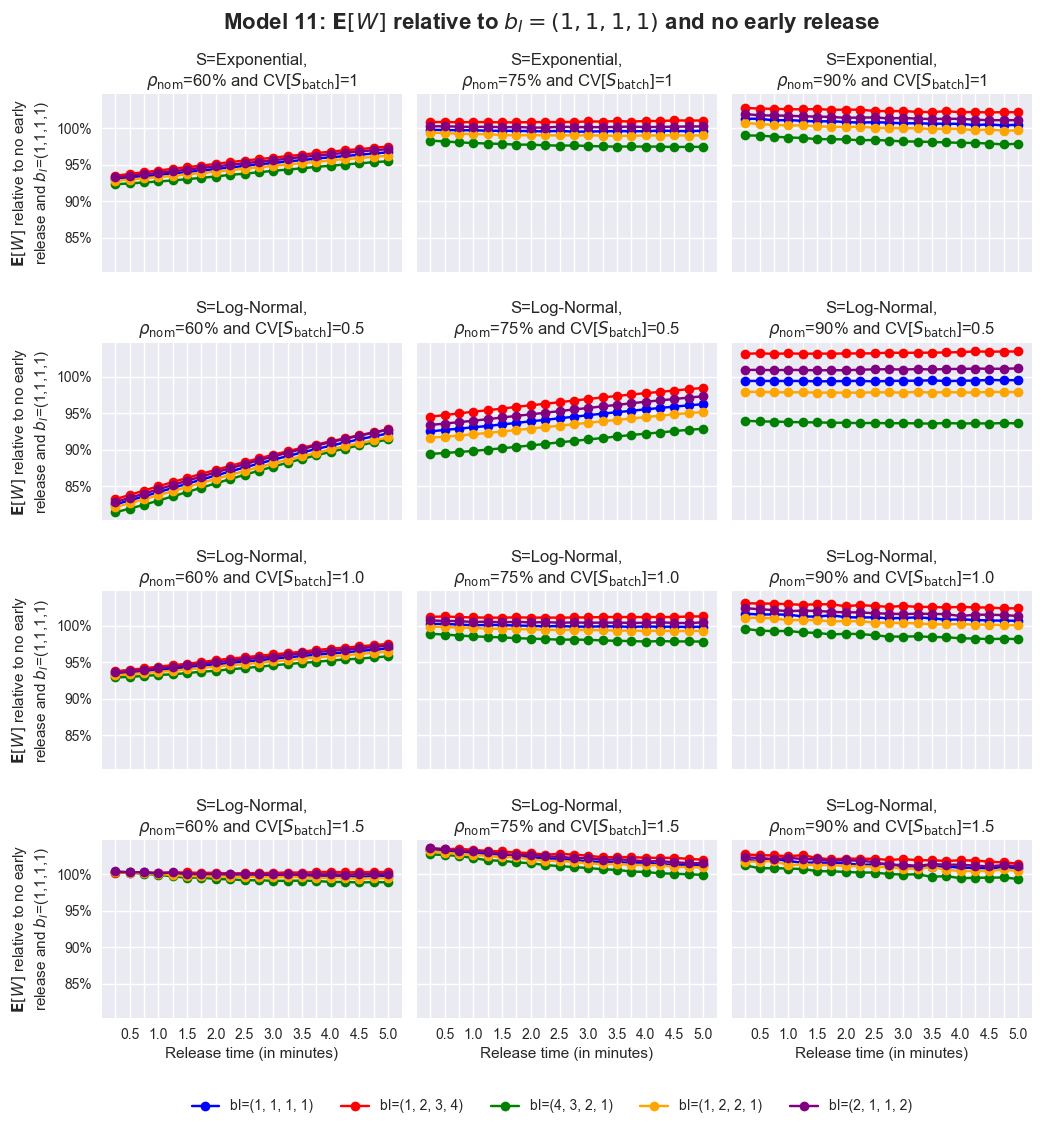

In [9]:
def plot_EWrel(ax, bI, color, label):
    for i in range(4):
        if i == 0:
            S = "Exp"
            S_name = "Exponential"
            CVS = 1
        else:
            S = "Log"
            S_name = "Log-Normal"
            CVS = 0.5 * i
        for j in range(3):
            rho = round(0.60 + j * 0.15, 2)
            plot_sim_data = []
            for rec in [r for r in data_bI1234 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho and r["bI"] == bI]:
                time = rec["time"]
                name = rec["name_short"]
                plot_sim_data.append({"time": time, "name": name, "E[W]": rec["E[W]rel"]})

            plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["time"])

            x = [rec["time"] / 60 for rec in plot_sim_data]
            y_sim = [rec["E[W]"] for rec in plot_sim_data]

            ax1 = ax[i][j]

            if i == 0 and j == 0:
                ax1.plot(x, y_sim, marker='o', color=color, label=label)
            else:
                ax1.plot(x, y_sim, marker='o', color=color)
            ax1.set_xticks(x)
            ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
            ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
            if j == 0:
                ax1.set_ylabel("$\\mathbf{{E}}[W]$ relative to no early\nrelease and $b_I$=(1,1,1,1)")

            if i == 3:
                ax1.set_xlabel("Release time (in minutes)")

            ax1.set_title(f"S={S_name},\n$\\rho_{{\\text{{nom}}}}$={rho * 100:0.0f}% and CV[$S_{{\\text{{batch}}}}$]={CVS}")


fig, ax = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)

for i, (bI_rate, color) in enumerate(zip(bI_rates_levels, colors)):
    bI_str = "".join(map(str, bI_rate))
    plot_EWrel(ax, bI_str, color, f"bI={tuple(bI_rate)}")

for j in range(3):
    ax1 = ax[3][j]
    for label in ax1.xaxis.get_ticklabels()[::2]:
        label.set_visible(False)

fig.suptitle("Model 11: $\\mathbf{E}[W]$ relative to $b_I=(1,1,1,1)$ and no early release", fontsize=16, fontweight="semibold", y=0.95)
fig.legend(loc='outside lower center', ncols=5, bbox_to_anchor=(0.5, 0.02), fontsize=10)
fig.subplots_adjust(wspace=0.05, hspace=0.4)

# fig.savefig("images/Model11-EWrel.png", format="png", bbox_inches='tight', pad_inches=0)

# fig.savefig("images/BatchArithmeticAndMitigation-figure-results-Model11-EWrel.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

### Plot batch sizes frequencies for $b_I=1,2,3,4$ (Model 11)

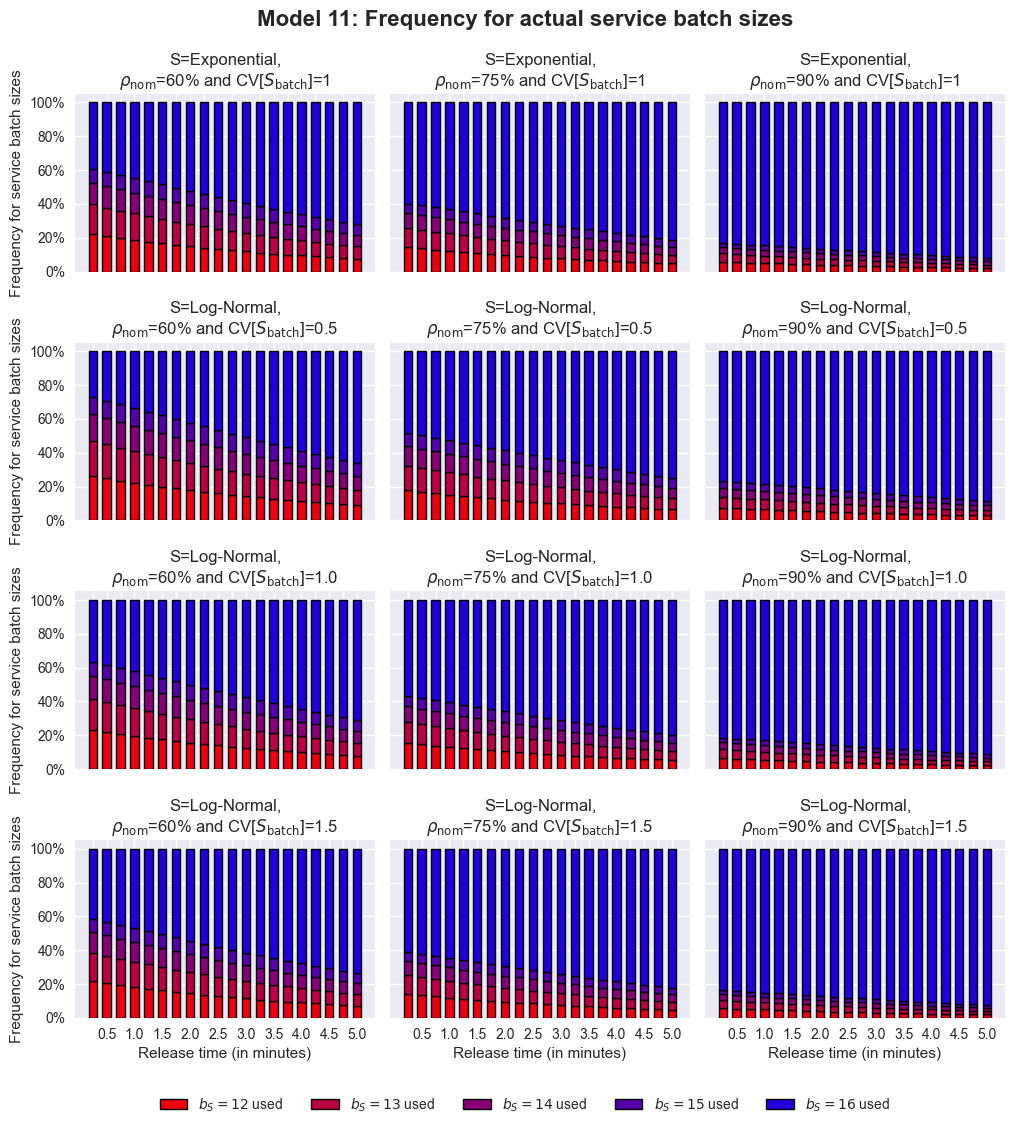

In [10]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        S_name = "Exponential"
        CVS = 1
    else:
        S = "Log"
        S_name = "Log-Normal"
        CVS = 0.5 * i
    for j in range(3):
        rho = round(0.60 + j * 0.15, 2)
        plot_sim_data = {}
        for rec in [r for r in data_bI1234 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            time = rec["time"]
            batch_sizes = rec["batch_sizes"]
            if time in plot_sim_data:
                plot_sim_data[time] = [plot_sim_data[time][k] + batch_sizes[k] for k in range(len(batch_sizes))]
            else:
                plot_sim_data[time] = batch_sizes

        x = sorted(list(plot_sim_data.keys()))
        x_plot=[time / 60 for time in x]

        ax1 = ax[i][j]
        bottom = [0] * len(x)
        for k in range(11, 16):
            above = [plot_sim_data[x_val][k]/5 for x_val in x]
            if i==0 and j==0:
                ax1.bar(x_plot, above, bottom=bottom, label=f"$b_S={k+1}$ used", color=bS_colors[16-3*(16-k)], edgecolor='black', linewidth=1, width=0.15)
            else:
                ax1.bar(x_plot, above, bottom=bottom, color=bS_colors[16-3*(16-k)], edgecolor='black', linewidth=1, width=0.15)
            bottom = [bottom[m] + above[m] for m in range(len(x))]

        ax1.set_xticks(x_plot)
        for label in ax1.xaxis.get_ticklabels()[::2]:
            label.set_visible(False)
        ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        if j == 0:
            ax1.set_ylabel("Frequency for service batch sizes")

        if i == 3:
            ax1.set_xlabel("Release time (in minutes)")

        ax1.set_title(f"S={S_name},\n$\\rho_{{\\text{{nom}}}}$={rho * 100:0.0f}% and CV[$S_{{\\text{{batch}}}}$]={CVS}")

fig.legend(loc='outside lower center', ncols=5, bbox_to_anchor=(0.5, 0.02), fontsize=10)
fig.suptitle("Model 11: Frequency for actual service batch sizes", fontsize=16, fontweight="semibold", y=0.95)
fig.subplots_adjust(wspace=0.05, hspace=0.4)

# fig.savefig("images/Model11-batch_sizes.png", format="png", bbox_inches='tight', pad_inches=0)